# Imports + helper functions

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import contextlib
import io

@contextlib.contextmanager
def suppress_stdout():
    buf = io.StringIO()
    with contextlib.redirect_stdout(buf):
        yield

from rabl.variography.DrumVariography import DrumProfileGenerator


def red_to_violet_colors(n: int):
    """Return n RGB colors from red (first) to violet (last)."""
    if n <= 0:
        return []
    if n == 1:
        return [(1.0, 0.0, 0.0)]
    hues = np.linspace(0.0, 0.75, n)  # 0.0=red, 0.75~violet
    hsv = np.column_stack([hues, np.ones(n), np.ones(n)])  # sat=1, val=1
    rgb = mcolors.hsv_to_rgb(hsv)
    return [tuple(map(float, c)) for c in rgb]


def build_t_grid(t_end: float, dt: float) -> np.ndarray:
    n = int(np.floor(t_end / dt)) + 1
    return np.linspace(0.0, t_end, n)

# User settings

In [4]:
# Fixed settings
kernel = "matern52"   # "matern32" or "matern52"
ell = 15
n_profiles = 20

# Sweep over these sigma targets (deg)
sigma_theta_targets = [2.5, 5, 10, 15, 20]

# Time grid
t_end = 200.0
dt = 0.1
t_grid = build_t_grid(t_end=t_end, dt=dt)

# Profile generation settings
baseline_angle_deg = 45.0
nugget = 0.0

# Plot settings
alpha = 1.0
linewidth = 1.0
seed = 123

# How to control the range of exploration for drum angles?
## Solving the velocity variogram sill to hit a target end-angle standard deviation

We sample **interval velocities** $v_j$ on the $M=N-1$ time intervals
$[t_j, t_{j+1}]$ with time steps $\Delta t_j = t_{j+1}-t_j$.

Using left-endpoint forward-Euler integration, the final drum angle is
$$
\theta_{N-1} = \theta_0 + \sum_{j=0}^{M-1} v_j\,\Delta t_j.
$$

We model the interval-velocity vector $\mathbf{v} = (v_0,\dots,v_{M-1})^\top$ as Gaussian with covariance
$$
\operatorname{Cov}(v_j, v_k) = s\,R_{jk}(\ell) + \eta\,\delta_{jk},
$$
where:
- $s$ is the **sill** (variance scale),
- $R_{jk}(\ell)$ is the Matérn **correlation** between intervals $j$ and $k$ at length scale $\ell$,
- $\eta$ is the **nugget** (often set to $0$),
- $\delta_{jk}$ is the Kronecker delta ($\delta_{jk}=1$ if $j=k$, else $0$).

Because $\theta_{N-1}$ is a weighted sum of Gaussian variables, its variance is
$$
\operatorname{Var}(\theta_{N-1})
= \sum_{j=0}^{M-1}\sum_{k=0}^{M-1} \Delta t_j\,\Delta t_k \,\operatorname{Cov}(v_j, v_k).
$$

Substituting the covariance model gives
$$
\operatorname{Var}(\theta_{N-1})
= s\sum_{j=0}^{M-1}\sum_{k=0}^{M-1} \Delta t_j\,\Delta t_k \,R_{jk}(\ell)
\;+\;
\eta\sum_{j=0}^{M-1} (\Delta t_j)^2.
$$

We choose $s$ so the final-angle standard deviation matches a target $\sigma_{\theta,\text{target}}$:
$$
\sqrt{\operatorname{Var}(\theta_{N-1})}=\sigma_{\theta,\text{target}}
\quad\Longleftrightarrow\quad
\operatorname{Var}(\theta_{N-1})=\sigma_{\theta,\text{target}}^2.
$$

Solving for the sill $s$ yields
$$
s
=
\frac{
\sigma_{\theta,\text{target}}^2
-
\eta\sum_{j=0}^{M-1} (\Delta t_j)^2
}{
\sum_{j=0}^{M-1}\sum_{k=0}^{M-1} \Delta t_j\,\Delta t_k \,R_{jk}(\ell)
}.
$$

**In words:**  
1) The final angle is the initial angle plus a sum of interval velocities times time steps.  
2) The variance of that sum is a double sum over all velocity covariances, weighted by $\Delta t_j\Delta t_k$.  
3) Since the covariance scales linearly with the sill $s$, the final-angle variance scales linearly with $s$.  
4) We solve the above equation for $s$ so the final-angle standard deviation matches the requested target.

# Generate + plot

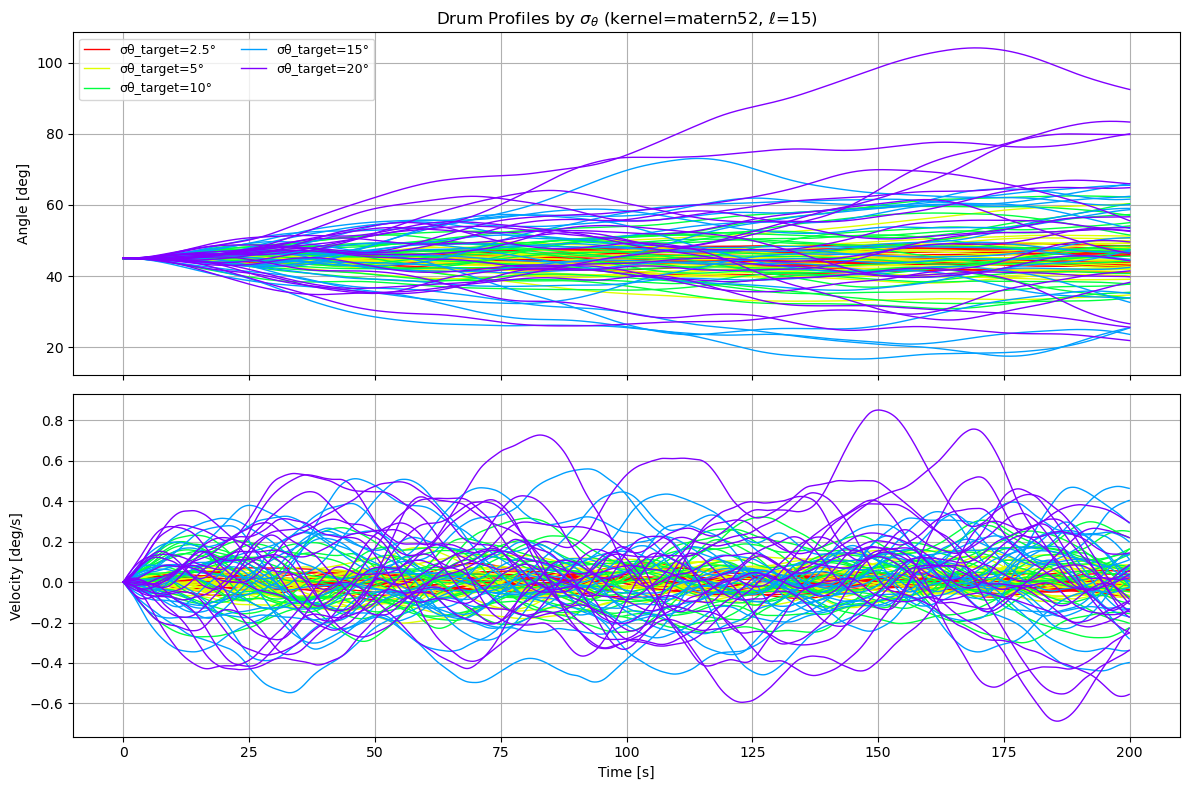


Target σθ vs realized σθ at t_end:
  target=  2.5000 deg   actual=  2.1648 deg   ratio= 0.8659
  target=  5.0000 deg   actual=  5.6041 deg   ratio= 1.1208
  target= 10.0000 deg   actual=  8.7487 deg   ratio= 0.8749
  target= 15.0000 deg   actual= 13.9321 deg   ratio= 0.9288
  target= 20.0000 deg   actual= 19.6200 deg   ratio= 0.9810


In [6]:
colors = red_to_violet_colors(len(sigma_theta_targets))

fig, (ax_th, ax_v) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

sigma_report = []  # (sigma_target, sigma_actual)

for k, (sigma, color) in enumerate(zip(sigma_theta_targets, colors)):
    # IMPORTANT: use a fresh generator per sigma to avoid issues when sill changes
    gen = DrumProfileGenerator(
        kernel=kernel,
        ell=ell,
        sill_v_deg2_s2=1.0,          # placeholder; overwritten by solve_params_for_sigma_theta
        nugget_v_deg2_s2=nugget,
    )

    gen.solve_params_for_sigma_theta(
        t_grid=t_grid,
        sigma_theta_target=sigma,
        ell=ell,
        nugget=nugget,
        update_instance=True,
    )

    seed_k = None if seed is None else (seed + 10_000 * k)

    # Suppress progress prints from generate()
    with suppress_stdout():
        profiles = gen.generate(
            t_grid=t_grid,
            n_realizations=n_profiles,
            baseline_angle_deg=baseline_angle_deg,
            seed=seed_k,
        )

    # Compute realized sigma at end time across profiles
    theta_end = np.array([p.theta_deg[-1] for p in profiles], dtype=float)
    sigma_actual = float(theta_end.std(ddof=1))  # sample std
    sigma_report.append((float(sigma), sigma_actual))

    # Plot all profiles for this sigma with the same color
    first = True
    for p in profiles:
        label = f"σθ_target={sigma:g}°" if first else None
        ax_th.plot(p.t, p.theta_deg, color=color, alpha=alpha, linewidth=linewidth, label=label)
        ax_v.plot(p.t, p.v_deg_s,  color=color, alpha=alpha, linewidth=linewidth)
        first = False

ax_th.set_title(fr"Drum Profiles by $\sigma_{{\theta}}$ (kernel={kernel}, $\ell$={ell:g})")
ax_th.set_ylabel("Angle [deg]")
ax_th.grid(True)
ax_th.legend(loc="best", fontsize=9, ncol=2)

ax_v.set_xlabel("Time [s]")
ax_v.set_ylabel("Velocity [deg/s]")
ax_v.grid(True)

plt.tight_layout()
plt.show()

print("\nTarget σθ vs realized σθ at t_end:")
for s_tgt, s_act in sigma_report:
    print(f"  target={s_tgt:8.4f} deg   actual={s_act:8.4f} deg   ratio={s_act/s_tgt:7.4f}")